# Trans-border Electricity Flows — Chord Diagram
Visualises net electricity trade flows between countries from OSeMBE results.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
import warnings
warnings.filterwarnings('ignore')

In [8]:
# ── Configuration ────────────────────────────────────────────────────────────
SCENARIO    = 'results/NamiraN_MSc_REF'
PLOT_YEARS  = [2030, 2050]          # years to plot
UNIT_LABEL  = 'GWh/yr'
PJ_TO_GWH   = 277.778               # 1 PJ = 277.778 GWh

COUNTRY_COLORS = {
    'AT': '#4e79a7', 'BE': '#f28e2b', 'BG': '#e15759', 'CH': '#76b7b2',
    'CY': '#59a14f', 'CZ': '#edc948', 'DE': '#b07aa1', 'DK': '#ff9da7',
    'EE': '#9c755f', 'ES': '#bab0ac', 'FI': '#17becf', 'FR': '#1f77b4',
    'GR': '#aec7e8', 'HR': '#ffbb78', 'HU': '#98df8a', 'IE': '#ff9896',
    'IT': '#c5b0d5', 'LT': '#c49c94', 'LU': '#f7b6d2', 'LV': '#c7c7c7',
    'MT': '#dbdb8d', 'NL': '#9edae5', 'NO': '#393b79', 'PL': '#637939',
    'PT': '#8c6d31', 'RO': '#843c39', 'SE': '#e6550d', 'SI': '#31a354',
    'SK': '#756bb1', 'UK': '#636363'
}

COUNTRY_NAMES = {
    'AT':'Austria','BE':'Belgium','BG':'Bulgaria','CH':'Switzerland',
    'CY':'Cyprus','CZ':'Czech Republic','DE':'Germany','DK':'Denmark',
    'EE':'Estonia','ES':'Spain','FI':'Finland','FR':'France',
    'GR':'Greece','HR':'Croatia','HU':'Hungary','IE':'Ireland',
    'IT':'Italy','LT':'Lithuania','LU':'Luxembourg','LV':'Latvia',
    'MT':'Malta','NL':'Netherlands','NO':'Norway','PL':'Poland',
    'PT':'Portugal','RO':'Romania','SE':'Sweden','SI':'Slovenia',
    'SK':'Slovakia','UK':'United Kingdom'
}

In [9]:
def load_trade_flows(scenario):
    """Load and parse electricity trade flows from ProductionByTechnologyAnnual.
    
    Technology naming: XXELYY = interconnector between XX and YY.
    FUEL country = destination (receiving electricity).
    Other country in tech name = source (sending electricity).
    Values are converted from PJ to GWh.
    """
    df = pd.read_csv(f'{scenario}/results_csv/ProductionByTechnologyAnnual.csv')

    # Keep only EL interconnection technologies (pattern: XXELYY...)
    mask = df['TECHNOLOGY'].str.match(r'^[A-Z]{2}EL[A-Z]{2}')
    df = df[mask].copy()

    df['tech_c1']   = df['TECHNOLOGY'].str[0:2]   # first country in tech name
    df['tech_c2']   = df['TECHNOLOGY'].str[4:6]   # second country in tech name
    df['fuel_ctry'] = df['FUEL'].str[0:2]          # country of fuel = destination

    # Source = the country in the tech name that is NOT the fuel country
    df['source'] = np.where(df['fuel_ctry'] == df['tech_c1'], df['tech_c2'], df['tech_c1'])
    df['dest']   = df['fuel_ctry']

    flows = df[['source', 'dest', 'YEAR', 'VALUE']].groupby(
        ['source', 'dest', 'YEAR'], as_index=False
    )['VALUE'].sum()

    # Convert PJ to GWh
    flows['VALUE'] = flows['VALUE'] * PJ_TO_GWH

    return flows


def build_flow_matrix(flows_df, year):
    """Build a country x country flow matrix for a given year (GWh/yr)."""
    df = flows_df[flows_df['YEAR'] == year]
    countries = sorted(set(df['source']).union(df['dest']))
    idx = {c: i for i, c in enumerate(countries)}
    n = len(countries)
    matrix = np.zeros((n, n))
    for _, row in df.iterrows():
        i, j = idx[row['source']], idx[row['dest']]
        matrix[i, j] += row['VALUE']
    return matrix, countries


flows = load_trade_flows(SCENARIO)
print(f"Loaded {len(flows)} flow records across {flows['YEAR'].nunique()} years")
flows.head()

Loaded 1928 flow records across 46 years


,source,dest,YEAR,VALUE
0,AT,CH,2015,3974.220509
1,AT,CH,2053,3071.174146
2,AT,CH,2054,3071.174146
3,AT,CH,2055,3071.174146
4,AT,CH,2056,3071.174146


In [10]:
def bezier_curve(p0, p1, p2, p3, n=50):
    """Cubic bezier curve through four control points."""
    t = np.linspace(0, 1, n)
    x = ((1-t)**3 * p0[0] + 3*(1-t)**2*t * p1[0] +
         3*(1-t)*t**2 * p2[0] + t**3 * p3[0])
    y = ((1-t)**3 * p0[1] + 3*(1-t)**2*t * p1[1] +
         3*(1-t)*t**2 * p2[1] + t**3 * p3[1])
    return x, y


def draw_chord_diagram(matrix, countries, colors, ax, title='',
                       r=1.0, arc_width=0.08, gap_deg=2.5):
    """
    Draw a chord diagram on ax.

    Parameters
    ----------
    matrix   : (n x n) array, matrix[i,j] = flow from i to j
    countries: list of country codes
    colors   : dict {country_code: color}
    r        : radius of the ring
    arc_width: radial width of the country arcs
    gap_deg  : gap between country arcs in degrees
    """
    n = len(countries)
    total_flow = matrix.sum(axis=1) + matrix.sum(axis=0)  # exports + imports
    # Avoid zero-division if a country has no flows
    total_flow = np.maximum(total_flow, 1e-9)

    gap = np.deg2rad(gap_deg)
    total_gap = n * gap
    available  = 2 * np.pi - total_gap
    arc_spans  = (total_flow / total_flow.sum()) * available

    # Start angle for each country arc
    starts = np.zeros(n)
    for i in range(1, n):
        starts[i] = starts[i-1] + arc_spans[i-1] + gap

    # ── Draw country arcs ────────────────────────────────────────────────────
    theta_fine = 200
    for i, country in enumerate(countries):
        color = colors.get(country, '#aaaaaa')
        theta = np.linspace(starts[i], starts[i] + arc_spans[i], theta_fine)
        r_outer = r + arc_width
        r_inner = r
        xs = np.concatenate([r_outer * np.cos(theta),
                              r_inner * np.cos(theta[::-1])])
        ys = np.concatenate([r_outer * np.sin(theta),
                              r_inner * np.sin(theta[::-1])])
        ax.fill(xs, ys, color=color, zorder=3)

        # Label
        mid = starts[i] + arc_spans[i] / 2
        lx = (r + arc_width + 0.12) * np.cos(mid)
        ly = (r + arc_width + 0.12) * np.sin(mid)
        ha = 'left' if np.cos(mid) >= 0 else 'right'
        ax.text(lx, ly, country, ha=ha, va='center',
                fontsize=9, fontweight='bold', color='black', zorder=5)

    # ── Pre-compute sub-arc positions within each country arc ────────────────
    # For country i, allocate sub-arcs proportional to individual flows
    sub_start_exp = {}  # sub_start_exp[i][j] = angle where i->j export sub-arc starts
    sub_start_imp = {}  # sub_start_imp[i][j] = angle where j->i import sub-arc starts (within i's arc)

    for i in range(n):
        exports = matrix[i]          # i -> each j
        imports = matrix[:, i]       # each j -> i
        combined = exports + imports
        total = combined.sum()
        if total < 1e-9:
            continue

        sub_spans = (combined / total) * arc_spans[i]
        cursor = starts[i]
        sub_start_exp[i] = {}
        sub_start_imp[i] = {}
        for j in range(n):
            if i == j:
                continue
            sub_start_exp[i][j] = cursor
            sub_start_imp[i][j] = cursor + (exports[j] / (combined[j] + 1e-12)) * sub_spans[j]
            cursor += sub_spans[j]

    # ── Draw chords ──────────────────────────────────────────────────────────
    drawn = set()
    for i in range(n):
        for j in range(i+1, n):
            flow_ij = matrix[i, j]
            flow_ji = matrix[j, i]
            total   = flow_ij + flow_ji
            if total < 0.01:
                continue
            if (i, j) in drawn:
                continue
            drawn.add((i, j))

            # Dominant direction determines color
            dominant = i if flow_ij >= flow_ji else j
            color = colors.get(countries[dominant], '#aaaaaa')
            alpha = min(0.7, 0.2 + 0.5 * (total / matrix.sum()))

            # Angle spans for the chord at each end
            if i not in sub_start_exp or j not in sub_start_exp:
                continue
            if j not in sub_start_exp.get(i, {}) or i not in sub_start_exp.get(j, {}):
                continue

            a1_start = sub_start_exp[i][j]
            a1_span  = (total / (matrix[i].sum() + matrix[:, i].sum() + 1e-12)) * arc_spans[i]
            a1_mid   = a1_start + a1_span / 2

            a2_start = sub_start_exp[j][i]
            a2_span  = (total / (matrix[j].sum() + matrix[:, j].sum() + 1e-12)) * arc_spans[j]
            a2_mid   = a2_start + a2_span / 2

            # Control points: pull toward centre
            scale = 0.0  # 0 = straight through centre
            p0 = (r * np.cos(a1_mid), r * np.sin(a1_mid))
            p3 = (r * np.cos(a2_mid), r * np.sin(a2_mid))
            p1 = (scale * p0[0], scale * p0[1])
            p2 = (scale * p3[0], scale * p3[1])

            xb, yb = bezier_curve(p0, p1, p2, p3, n=80)

            # Chord width proportional to flow
            lw = 0.5 + 8 * (total / (matrix.sum() + 1e-9))
            ax.plot(xb, yb, color=color, alpha=alpha,
                    linewidth=lw, solid_capstyle='round', zorder=2)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

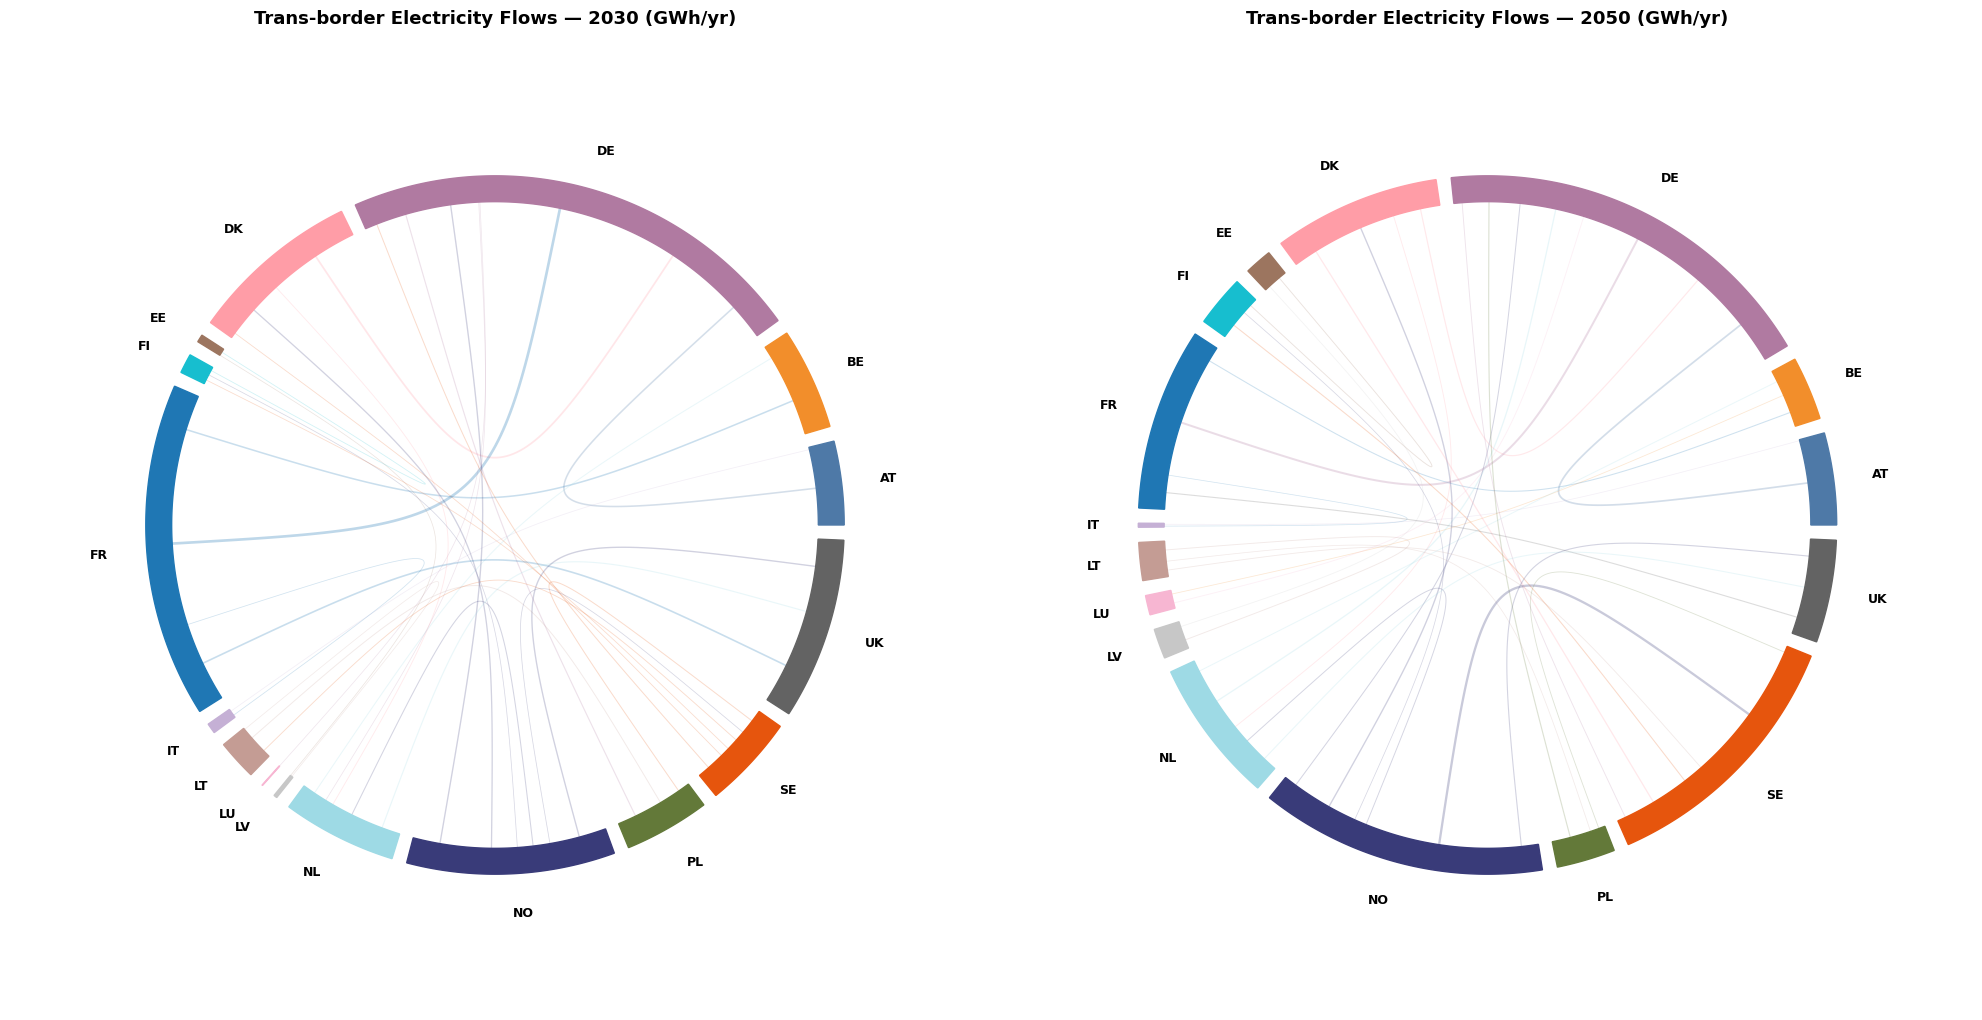

Saved to results/transborder_flows.png


In [11]:
# ── Plot chord diagrams for selected years ───────────────────────────────────
fig, axes = plt.subplots(1, len(PLOT_YEARS), figsize=(10 * len(PLOT_YEARS), 10))
if len(PLOT_YEARS) == 1:
    axes = [axes]

for ax, year in zip(axes, PLOT_YEARS):
    matrix, countries = build_flow_matrix(flows, year)
    draw_chord_diagram(
        matrix, countries, COUNTRY_COLORS, ax,
        title=f'Trans-border Electricity Flows — {year} ({UNIT_LABEL})'
    )

plt.tight_layout()
plt.savefig('results/transborder_flows.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/transborder_flows.png')

In [12]:
# ── Summary table: top flows for a given year ────────────────────────────────
year = 2030
top = (
    flows[flows['YEAR'] == year]
    .sort_values('VALUE', ascending=False)
    .head(15)
    .assign(
        Source=lambda d: d['source'].map(COUNTRY_NAMES),
        Destination=lambda d: d['dest'].map(COUNTRY_NAMES),
        **{f'Flow ({UNIT_LABEL})': lambda d: d['VALUE'].round(1)}
    )[['Source', 'Destination', f'Flow ({UNIT_LABEL})']]
    .reset_index(drop=True)
)
print(f'Top 15 electricity trade flows in {year}:')
top

Top 15 electricity trade flows in 2030:


,Source,Destination,Flow (GWh/yr)
0,France,Germany,34092.6
1,Denmark,Germany,18305.9
2,France,United Kingdom,16644.0
3,Austria,Germany,15666.5
4,France,Belgium,14979.6
5,Norway,United Kingdom,11650.8
6,Norway,Germany,11628.3
7,Norway,Denmark,10375.3
8,Netherlands,United Kingdom,7925.3
9,Germany,Poland,7889.7
